In [30]:
import pandas as pd  # Import pandas library for data manipulation and analysis
import numpy as np   # Import numpy library for numerical operations
import matplotlib.pyplot as plt  # Import matplotlib for plotting graphs
import seaborn as sns  # Import seaborn for statistical data visualization


In [31]:
df = pd.read_csv("Advertising.xls")  # Read data from CSV file named "Advertising.xls" into a DataFrame
df.head()  # Display the first 5 rows of the DataFrame


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# EDA


In [32]:
df.shape  # Get the number of rows and columns in the DataFrame


(200, 5)

In [33]:
df.info()  # Display summary information about the DataFrame including data types and non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [34]:
df.describe()  # Generate descriptive statistics like mean, std, min, max, and quartiles for numerical columns


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [35]:
df.duplicated().sum()  # Count the number of duplicate rows in the DataFrame


np.int64(0)

In [36]:
df.isnull().sum()  # Count the number of missing (null) values in each column of the DataFrame


Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [37]:
df.value_counts()  # Count the frequency of each unique row combination in the DataFrame


Unnamed: 0  TV     Radio  Newspaper  Sales
1           230.1  37.8   69.2       22.1     1
138         273.7  28.9   59.7       20.8     1
128         80.2   0.0    9.2        8.8      1
129         220.3  49.0   3.2        24.7     1
130         59.6   12.0   43.1       9.7      1
                                             ..
70          216.8  43.9   27.2       22.3     1
71          199.1  30.6   38.7       18.3     1
72          109.8  14.3   31.7       12.4     1
73          26.8   33.0   19.3       8.8      1
200         232.1  8.6    8.7        13.4     1
Name: count, Length: 200, dtype: int64

<Axes: xlabel='Newspaper'>

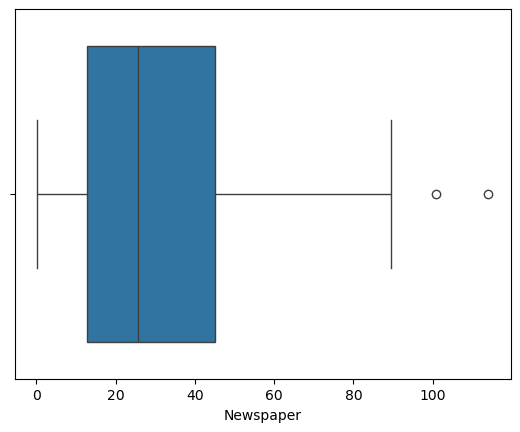

In [38]:
sns.boxplot(x=df['Newspaper'])  # Create a boxplot to visualize the distribution and outliers of the 'Newspaper' column


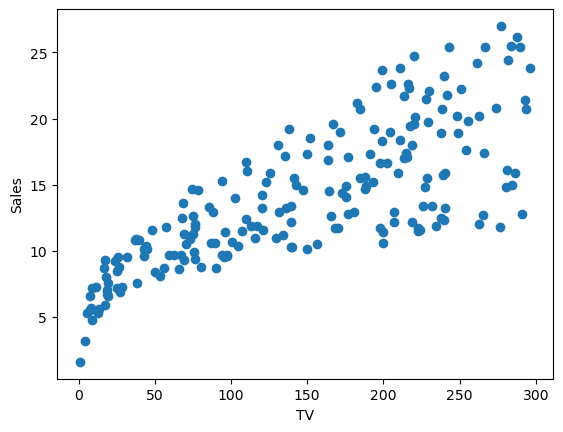

In [39]:
plt.scatter(df['TV'], df['Sales'])  # Create a scatter plot of TV advertising vs Sales
plt.xlabel('TV')  # Label x-axis as 'TV'
plt.ylabel('Sales')  # Label y-axis as 'Sales'
plt.show()  # Display the plot


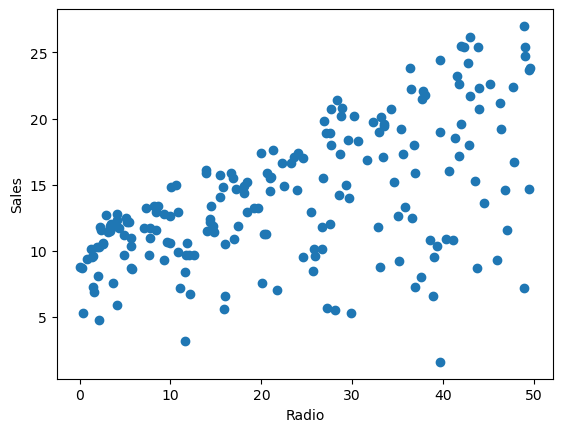

In [40]:
plt.scatter(df['Radio'], df['Sales'])  # Create a scatter plot of Radio advertising vs Sales
plt.xlabel('Radio')  # Label x-axis as 'Radio'
plt.ylabel('Sales')  # Label y-axis as 'Sales'
plt.show()  # Display the plot


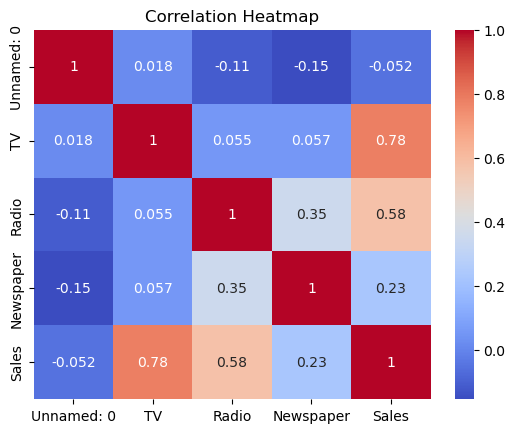

In [41]:
corr = df.corr()  # Calculate the correlation matrix for all numerical columns in the DataFrame

sns.heatmap(corr, annot=True, cmap='coolwarm')  # Create a heatmap with correlation values annotated, using the 'coolwarm' color map
plt.title('Correlation Heatmap')  # Set the title of the heatmap
plt.show()  # Display the heatmap


In [42]:
correlations = df.corr()  # Calculate the correlation matrix for the DataFrame

print(correlations['Sales'].sort_values(ascending=False))  # Print the correlation values of all features with 'Sales', sorted from highest to lowest


Sales         1.000000
TV            0.782224
Radio         0.576223
Newspaper     0.228299
Unnamed: 0   -0.051616
Name: Sales, dtype: float64


In [43]:
df.dtypes  # Display the data type of each column in the DataFrame

Unnamed: 0      int64
TV            float64
Radio         float64
Newspaper     float64
Sales         float64
dtype: object

# Data cleaning


In [44]:
df = df.drop(columns=['Unnamed: 0'])  # Drop the column named 'Unnamed: 0' from the DataFrame


In [45]:
print(df.columns)  # Print the names of all columns in the DataFrame

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


# Data Preparation & Feature Engineering


In [46]:
df['TV_Radio'] = df['TV'] * df['Radio']  # Create a new feature by multiplying TV and Radio
df['TV_Newspaper'] = df['TV'] * df['Newspaper']  # Create a new feature by multiplying TV and Newspaper
df['Radio_Newspaper'] = df['Radio'] * df['Newspaper']  # Create a new feature by multiplying Radio and Newspaper

df['TV_squared'] = df['TV'] ** 2  # Create a new feature by squaring TV values
df['Radio_squared'] = df['Radio'] ** 2  # Create a new feature by squaring Radio values
df['Newspaper_squared'] = df['Newspaper'] ** 2  # Create a new feature by squaring Newspaper values

df['log_TV'] = np.log1p(df['TV'])  # Create a new feature by applying log(1 + x) transformation to TV values

print(df.head())  # Display the first 5 rows of the updated DataFrame


      TV  Radio  Newspaper  Sales  TV_Radio  TV_Newspaper  Radio_Newspaper  \
0  230.1   37.8       69.2   22.1   8697.78      15922.92          2615.76   
1   44.5   39.3       45.1   10.4   1748.85       2006.95          1772.43   
2   17.2   45.9       69.3    9.3    789.48       1191.96          3180.87   
3  151.5   41.3       58.5   18.5   6256.95       8862.75          2416.05   
4  180.8   10.8       58.4   12.9   1952.64      10558.72           630.72   

   TV_squared  Radio_squared  Newspaper_squared    log_TV  
0    52946.01        1428.84            4788.64  5.442851  
1     1980.25        1544.49            2034.01  3.817712  
2      295.84        2106.81            4802.49  2.901422  
3    22952.25        1705.69            3422.25  5.027165  
4    32688.64         116.64            3410.56  5.202907  


In [47]:
print(df.columns)  # Print the names of all columns in the updated DataFrame


Index(['TV', 'Radio', 'Newspaper', 'Sales', 'TV_Radio', 'TV_Newspaper',
       'Radio_Newspaper', 'TV_squared', 'Radio_squared', 'Newspaper_squared',
       'log_TV'],
      dtype='object')


In [48]:
X = df.drop(columns='Sales')  # Define feature matrix X by dropping the 'Sales' column
y = df['Sales']  # Define target variable y as the 'Sales' column


In [49]:
print(X.columns)  # Print the names of all feature columns in X


Index(['TV', 'Radio', 'Newspaper', 'TV_Radio', 'TV_Newspaper',
       'Radio_Newspaper', 'TV_squared', 'Radio_squared', 'Newspaper_squared',
       'log_TV'],
      dtype='object')


In [50]:
from sklearn.model_selection import train_test_split  # Import train_test_split to split data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # Split the dataset into training and testing sets (80% train, 20% test)


In [51]:
df.to_csv('cleaned_data.csv', index=False)  # Save the DataFrame to a CSV file without writing row indices


# Model Building


In [52]:
from sklearn.linear_model import LinearRegression   # Import Linear Regression model

model = LinearRegression()   # Create a Linear Regression model instance
model.fit(X_train, y_train)   # Train the model on the training data


LinearRegression()

In [53]:
y_pred = model.predict(X_test)   # Predict unemployment rates using the trained model on the test data


In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # Import evaluation metrics

mae = mean_absolute_error(y_test, y_pred)   # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)   # Mean Squared Error
rmse = np.sqrt(mse)   # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)   # R² Score (Coefficient of Determination)

print("MAE:", mae)   # Print MAE
print("MSE:", mse)   # Print MSE
print("RMSE:", rmse)   # Print RMSE
print("R² Score:", r2)   # Print R² Score


MAE: 0.32984212298465676
MSE: 0.16502377589427925
RMSE: 0.40623118528035146
R² Score: 0.9947717051105982


In [55]:
best_rf = LinearRegression()  # Create an instance of the LinearRegression model


In [56]:
import joblib   # Import joblib for saving models and objects

joblib.dump(best_rf, 'Advertising.pkl')   # Save the best Random Forest model to a file


['Advertising.pkl']